# Sum of Hail (Accumulation)

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [17]:
import intake

cat = intake.open_catalog("https://tcodata.mpimet.mpg.de/catalog.yaml")
wxt = cat.BCO.surfacemet_wxt_v1.to_dask()

In [30]:
wxt

<xarray.Dataset> Size: 5GB
Dimensions:      (time: 43647315, bnd: 2)
Coordinates:
    alt          float64 8B ...
    lat          float64 8B ...
    lon          float64 8B ...
  * time         (time) datetime64[ns] 349MB 2010-12-16T16:24:00 ... 2026-03-...
Dimensions without coordinates: bnd
Data variables: (12/22)
    DIR          (time) float32 175MB dask.array<chunksize=(262144,), meta=np.ndarray>
    DL           (time) float32 175MB dask.array<chunksize=(262144,), meta=np.ndarray>
    DR           (time) float32 175MB dask.array<chunksize=(262144,), meta=np.ndarray>
    H            (time) float32 175MB dask.array<chunksize=(262144,), meta=np.ndarray>
    HDS          (time) float32 175MB dask.array<chunksize=(262144,), meta=np.ndarray>
    HI           (time) float32 175MB dask.array<chunksize=(262144,), meta=np.ndarray>
    ...           ...
    TI           (time) float32 175MB dask.array<chunksize=(262144,), meta=np.ndarray>
    VEL          (time) float32 175MB dask.array<chunksize=(262144,), meta=np.ndarray>
    VH           (time) float32 175MB dask.array<chunksize=(262144,), meta=np.ndarray>
    VR           (time) float32 175MB dask.array<chunksize=(262144,), meta=np.ndarray>
    VS           (time) float32 175MB dask.array<chunksize=(262144,), meta=np.ndarray>
    time_bounds  (time, bnd) datetime64[ns] 698MB dask.array<chunksize=(262144, 2), meta=np.ndarray>
Attributes:
    Conventions:      CF-1.12
    bcoproc_version:  0.0.0.post617.dev0+72301e9
    institution:      Max Planck Institute for Meteorology, Hamburg
    license:          CC0-1.0
    location:         The Barbados Cloud Observatory, Deebles Point, Barbados...
    platform:         BCO
    source:           Vaisala WXT-520
    summary:          This dataset contains basic meteorological measurements...
    title:            WXT-2 ground station data from BCO (Level 1)
    tool_versions:    {"Python": "3.11.2 (main, Apr 28 2025, 14:11:48) [GCC 1...

## Hail Accumulation Info

In [18]:
hail = wxt["H"]

print(hail)
print("\n", hail.attrs)
print("\n", hail.encoding)
print("\nDimensions: ", hail.dims)
print("\nShape: ", hail.shape)
print(f"\nMin/Max: {float(hail.min())}/{float(hail.max())}")

<xarray.DataArray 'H' (time: 43647315)> Size: 175MB
dask.array<open_dataset-H, shape=(43647315,), dtype=float32, chunksize=(262144,), chunktype=numpy.ndarray>
Coordinates:
    alt      float64 8B ...
    lat      float64 8B ...
    lon      float64 8B ...
  * time     (time) datetime64[ns] 349MB 2010-12-16T16:24:00 ... 2026-03-01T2...
Attributes:
    cell_methods:  time: sum
    long_name:     sum of hail within 10 sec time bin
    units:         cm-2

 {'cell_methods': 'time: sum', 'long_name': 'sum of hail within 10 sec time bin', 'units': 'cm-2'}

 {'chunks': (262144,), 'preferred_chunks': {'time': 262144}, 'compressor': Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0), 'filters': None, '_FillValue': nan, 'dtype': dtype('float32'), 'coordinates': 'alt lat lon'}

Dimensions:  ('time',)

Shape:  (43647315,)

Min/Max: 0.0/384.0


Barbados has not had hail events in the last 16 years. Thus, the $384\,cm^{-2}$ is spurious. We investigate the other values to see what they look like.

In [19]:
# Compute the max value
hail_max = hail.max()
print(f"\nMax hail: {hail_max.values}")

# Count values above 0
hail_above_zero = (hail > 0).sum()
print(f"\nNumber of hail values above 0: {hail_above_zero.values}")

# List these values
hail_above_zero_values = hail.where(hail > 0).dropna("time", how="all")
print(f"\nHail values above 0: \n{hail_above_zero_values.values}")


Max hail: 384.0

Number of hail values above 0: 13

Hail values above 0: 
[384.  38.  96.  52.  61.  53.  44. 122.   8.   1.   8.   1.   1.]


There are $13$ hail events in the dataset. Now, we check the timesteps of these hail events.

In [21]:
hail_events = hail.where(hail > 0).dropna("time", how="all")
hail_event_times = hail_events["time"]
print(f"\nTimes of hail events: \n{hail_event_times.values}")


Times of hail events: 
['2011-10-22T13:28:40.000000000' '2011-10-22T13:28:50.000000000'
 '2012-06-12T17:45:40.000000000' '2012-06-12T17:45:50.000000000'
 '2012-06-12T17:46:00.000000000' '2012-06-12T17:46:10.000000000'
 '2012-06-12T17:46:20.000000000' '2012-06-12T17:47:50.000000000'
 '2014-10-05T07:52:50.000000000' '2014-10-05T13:19:40.000000000'
 '2014-10-05T13:29:00.000000000' '2014-10-05T14:40:20.000000000'
 '2014-10-05T14:40:30.000000000']


In [22]:
print("Local times of hail events:\n")
print(f"{hail_event_times.values - np.timedelta64(4, 'h')}")

Local times of hail events:

['2011-10-22T09:28:40.000000000' '2011-10-22T09:28:50.000000000'
 '2012-06-12T13:45:40.000000000' '2012-06-12T13:45:50.000000000'
 '2012-06-12T13:46:00.000000000' '2012-06-12T13:46:10.000000000'
 '2012-06-12T13:46:20.000000000' '2012-06-12T13:47:50.000000000'
 '2014-10-05T03:52:50.000000000' '2014-10-05T09:19:40.000000000'
 '2014-10-05T09:29:00.000000000' '2014-10-05T10:40:20.000000000'
 '2014-10-05T10:40:30.000000000']


## Hail Events
1. This covers the first two hail events. There were no thunderstorms in the vicinity so this measurement is spurious.

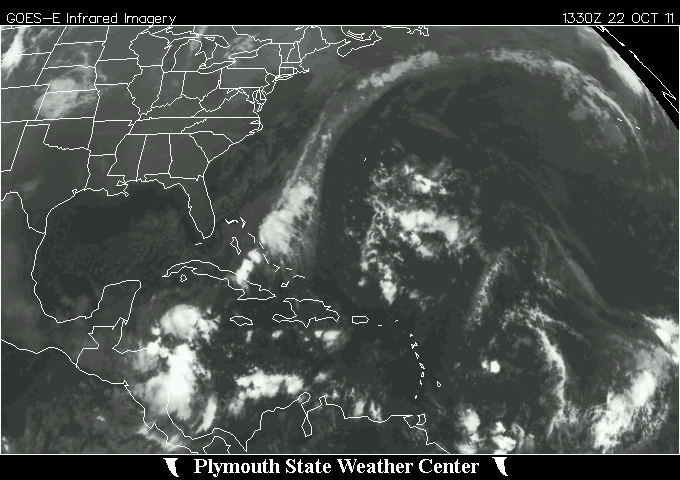

https://vortex.plymouth.edu/wxp/cgi-bin/sat/gen-archsat.cgi?region=atl_sat&yy=2011&mm=10&dd=22&hh=13&loop=no

2. This covers the next six hail events. There is some weather about due to a passing Tropical Wave. However, the satellite features do not suggest that there should be any major hail events at the BCO during this period.

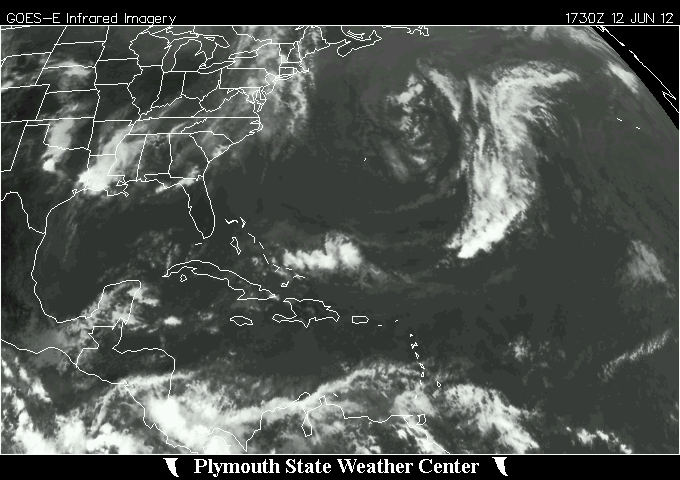

https://vortex.plymouth.edu/wxp/cgi-bin/sat/gen-archsat.cgi?region=atl_sat&yy=2012&mm=06&dd=12&hh=17&loop=no

3. The remainder of events occured on June $5^\mathrm{th}$, 2014. There are no significant features near Barbados during this time.

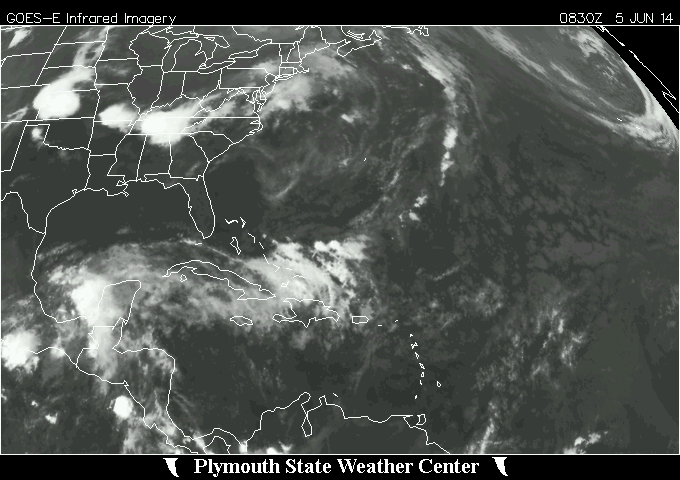

https://vortex.plymouth.edu/wxp/cgi-bin/sat/gen-archsat.cgi?region=atl_sat&yy=2014&mm=06&dd=05&hh=08&loop=no

# Hail Intensity
The dataset also has a variable called "Hail Intensity", labelled "HI" in the dataset. It measures the mean hail intensity per hour.

In [23]:
hail_intensity = wxt["HI"]
hail_intensity

<xarray.DataArray 'HI' (time: 43647315)> Size: 175MB
dask.array<open_dataset-HI, shape=(43647315,), dtype=float32, chunksize=(262144,), chunktype=numpy.ndarray>
Coordinates:
    alt      float64 8B ...
    lat      float64 8B ...
    lon      float64 8B ...
  * time     (time) datetime64[ns] 349MB 2010-12-16T16:24:00 ... 2026-03-01T2...
Attributes:
    cell_methods:  time: mean
    long_name:     mean hail intensity
    units:         cm-2 h-1

In [24]:
print(hail_intensity)
print("\n", hail_intensity.attrs)
print("\n", hail_intensity.encoding)
print("\nDimensions: ", hail_intensity.dims)
print("\nShape: ", hail_intensity.shape)
print(f"\nMin/Max: {float(hail_intensity.min())}/{float(hail_intensity.max())}")

# Count values above 0
hail_intensity_above_zero = (hail_intensity > 0).sum()
print(f"\nNumber of hail intensity values above 0: {hail_intensity_above_zero.values}")

# List these values
hail_intensity_above_zero_values = hail_intensity.where(hail_intensity > 0).dropna("time", how="all")
print(f"\nHail intensity values above 0: \n{hail_intensity_above_zero_values.values}")

<xarray.DataArray 'HI' (time: 43647315)> Size: 175MB
dask.array<open_dataset-HI, shape=(43647315,), dtype=float32, chunksize=(262144,), chunktype=numpy.ndarray>
Coordinates:
    alt      float64 8B ...
    lat      float64 8B ...
    lon      float64 8B ...
  * time     (time) datetime64[ns] 349MB 2010-12-16T16:24:00 ... 2026-03-01T2...
Attributes:
    cell_methods:  time: mean
    long_name:     mean hail intensity
    units:         cm-2 h-1

 {'cell_methods': 'time: mean', 'long_name': 'mean hail intensity', 'units': 'cm-2 h-1'}

 {'chunks': (262144,), 'preferred_chunks': {'time': 262144}, 'compressor': Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0), 'filters': None, '_FillValue': nan, 'dtype': dtype('float32'), 'coordinates': 'alt lat lon'}

Dimensions:  ('time',)

Shape:  (43647315,)

Min/Max: 0.0/9.848999977111816

Number of hail intensity values above 0: 69

Hail intensity values above 0: 
[9.849 5.133 5.824 5.255 5.1   5.005 4.861 8.438 2.133 1.667 0.133 0.267
 0.62

Immediately, there is a mismatch between the "Hail accumulation" and "Hail intensity" events. We have $69$ hail intensity events. The following lists the timestamps of these events.

In [25]:
hail_intensity_events = hail_intensity.where(hail_intensity > 0).dropna("time", how="all")
hail_intensity_event_times = hail_intensity_events["time"]
print(f"\nTimes of hail intensity events: \n{hail_intensity_event_times.values}")


Times of hail intensity events: 
['2011-10-22T13:28:40.000000000' '2011-10-22T13:28:50.000000000'
 '2012-06-12T17:45:40.000000000' '2012-06-12T17:45:50.000000000'
 '2012-06-12T17:46:00.000000000' '2012-06-12T17:46:10.000000000'
 '2012-06-12T17:46:20.000000000' '2012-06-12T17:47:50.000000000'
 '2014-01-28T16:00:20.000000000' '2014-10-05T06:58:50.000000000'
 '2014-10-05T07:54:50.000000000' '2014-10-05T11:28:40.000000000'
 '2014-10-05T12:32:30.000000000' '2014-10-05T13:18:50.000000000'
 '2016-01-02T08:15:10.000000000' '2016-01-02T08:15:20.000000000'
 '2016-01-02T08:15:30.000000000' '2016-01-02T08:15:40.000000000'
 '2016-01-02T08:15:50.000000000' '2016-01-02T08:16:00.000000000'
 '2016-01-02T08:16:10.000000000' '2016-08-20T01:49:40.000000000'
 '2016-08-20T01:49:50.000000000' '2016-08-20T01:50:00.000000000'
 '2016-08-20T01:50:10.000000000' '2016-08-20T01:50:20.000000000'
 '2016-08-20T01:50:30.000000000' '2016-08-20T01:50:40.000000000'
 '2017-11-14T13:07:10.000000000' '2017-11-14T13:07:20.00

# Hail Duration
The final variable pertaining to hail is the `hail duration` which is measured in seconds. Let of have a closer look at this variable.

In [26]:
hail_duration = wxt["HDS"]
hail_duration

<xarray.DataArray 'HDS' (time: 43647315)> Size: 175MB
dask.array<open_dataset-HDS, shape=(43647315,), dtype=float32, chunksize=(262144,), chunktype=numpy.ndarray>
Coordinates:
    alt      float64 8B ...
    lat      float64 8B ...
    lon      float64 8B ...
  * time     (time) datetime64[ns] 349MB 2010-12-16T16:24:00 ... 2026-03-01T2...
Attributes:
    cell_methods:  time: sum
    long_name:     duration of hail in second
    units:         s

In [27]:
# Compute the max value
hail_duration_max = hail_duration.max()
print(f"\nMax hail duration: {hail_duration_max.values}")

# Count values above 0
hail_duration_above_zero = (hail_duration > 0).sum()
print(f"\nNumber of hail duration values above 0: {hail_duration_above_zero.values}")

# List these values
hail_duration_events = hail_duration.where(hail_duration > 0).dropna("time", how="all")
print(f"\nHail duration values above 0: \n{hail_duration_events.values}")


Max hail duration: 999.0

Number of hail duration values above 0: 20

Hail duration values above 0: 
[192.   19.2  48.4  26.4  30.8  26.4  22.   61.5   2.    1.  999.    8.
  10.   10.   10.   10.   10.   10.   10.   10. ]


In [28]:
# Compute the start times and end times.
start_times = hail_duration_events["time"].values
durations = hail_duration_events.values.astype(int)

end_times = start_times + durations.astype("timedelta64[s]")

## Plot of Hail Events and hail times

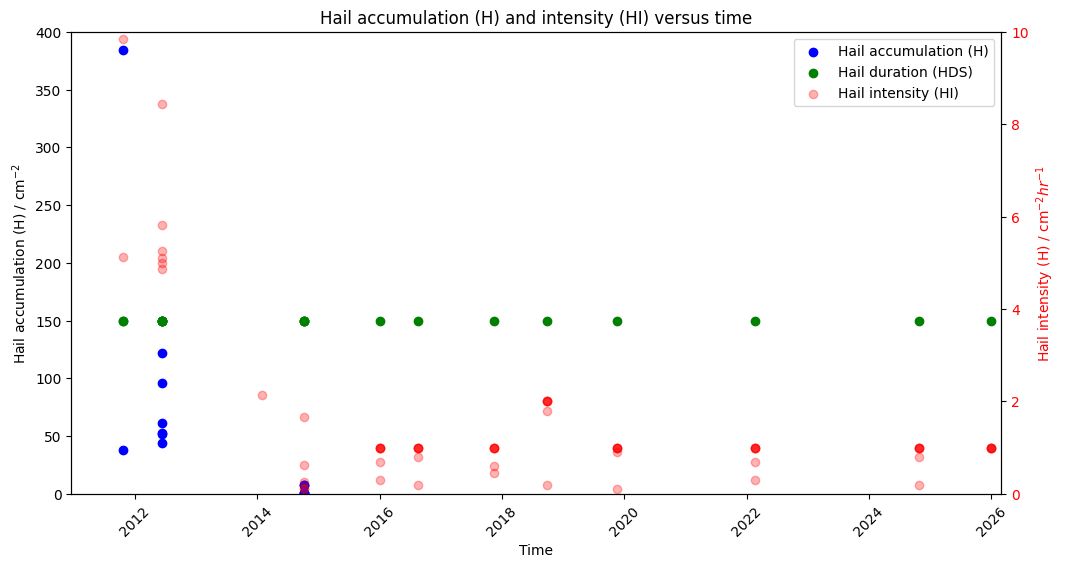

In [40]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Hail accumulation
ax1.scatter(
    hail_events["time"],
    hail_events,
    color="blue",
    label="Hail accumulation (H)",
    zorder=1
)
ax1.hlines(
    y=np.full(len(start_times), 150),
    xmin=start_times,
    xmax=end_times,
    color="green",
    linewidth=3,
    label="Hail duration (HDS)",
    zorder=2
)
# ax1.scatter(
#     hail_duration_events["time"],
#     np.full(len(hail_duration_events), 0),
#     color="green"
# )
ax1.set_xlabel("Time")
ax1.set_ylabel("Hail accumulation (H) / cm$^{-2}$")
ax1.set_title("Hail accumulation (H) and intensity (HI) versus time")
ax1.set_ylim(0, 400)
ax1.set_xlim(hail["time"].min(), hail["time"].max())
ax1.legend()

# Hail intensity
ax2 = ax1.twinx()
ax2.scatter(
    hail_intensity_events["time"],
    hail_intensity_events,
    color="red",
    label="Hail intensity (HI)",
    zorder=2
)
ax2.set_ylabel(r"Hail intensity (H) / cm$^{-2}hr^{-1}\,$", color="red")
ax2.tick_params(axis="y", labelcolor="red")
ax2.set_ylim(0, 10)
ax2.legend()

plt.show()

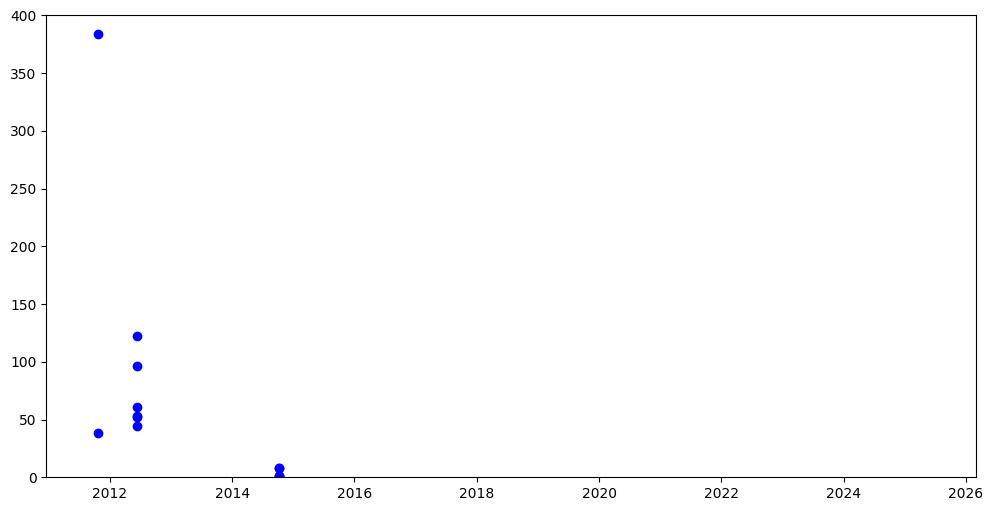

In [91]:
print(start_times[:5])
print(end_times[:5])


In [74]:
start_times.shape

(20,)

In [75]:
end_times.shape

(20,)

In [76]:
end_times = start_times + hail_duration_events.values.astype("timedelta64[s]")

In [77]:
end_times

array(['2011-10-22T13:31:52.000000000', '2011-10-22T13:29:09.000000000',
       '2012-06-12T17:46:28.000000000', '2012-06-12T17:46:16.000000000',
       '2012-06-12T17:46:30.000000000', '2012-06-12T17:46:36.000000000',
       '2012-06-12T17:46:42.000000000', '2012-06-12T17:48:51.000000000',
       '2014-10-05T08:20:42.000000000', '2014-10-05T11:27:11.000000000',
       '2014-10-05T12:49:29.000000000', '2014-10-05T13:20:58.000000000',
       '2016-01-02T08:15:20.000000000', '2016-08-20T01:49:50.000000000',
       '2017-11-14T13:07:20.000000000', '2018-09-25T00:50:30.000000000',
       '2019-11-19T21:24:50.000000000', '2022-02-17T23:40:40.000000000',
       '2024-10-25T06:54:10.000000000', '2025-12-30T04:07:30.000000000'],
      dtype='datetime64[ns]')